In [1]:
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
from importlib import reload
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [3]:
from pathlib import Path

FIG_SAVE_PATH = Path("../results/figures/3.task_structure")

In [4]:
# load data for regions plot
from GridMaze.analysis.anatomy import regions

region_counts_df = regions.get_subject_cell_counts(ignore_layers=True)

/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code/GridMaze/analysis/anatomy/regions.py:77: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df.fillna(0, inplace=True)


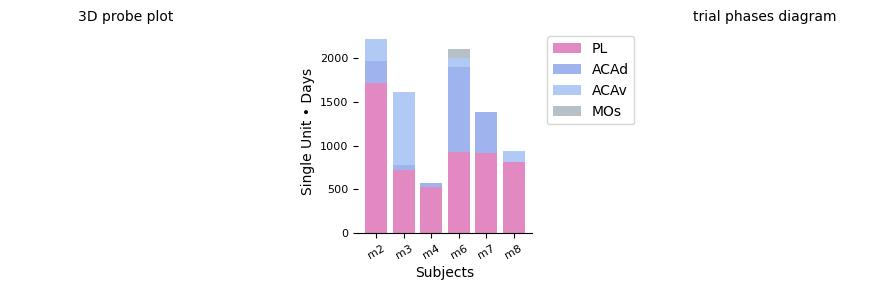

In [5]:
# we recorded cells
fig1, axes = plt.subplots(1, 3, figsize=(9, 3), clear=True, width_ratios=[1, 0.75, 1])
axes[0].set_title("3D probe plot")
axes[0].axis("off")
axes[2].set_title("trial phases diagram")
axes[2].axis("off")
regions.plot_subject_cell_counts(region_counts_df, ax=axes[1])
fig1.tight_layout()

In [6]:
from GridMaze.analysis.event_aligned import population_activity as pa

reload(pa)

aligned_activity_df = pa.get_aligned_population_activity(aligned_to="trial")

In [ ]:
# lfp figure
from GridMaze.analysis.event_aligned import spectrograms

signal_type = "LFP"  # LFP or CSD

spectrogram_df = spectrograms.load_spectrogram_df(signal_type)
PSD_df = spectrograms.load_PSD_df(signal_type)

In [ ]:
reload(pa)
reload(spectrograms)
# where single unit population activty was locked to trial events
fig2, axes = plt.subplots(1, 2, figsize=(9.5, 2.75), clear=True, width_ratios=[1, 0.4])
pa._plot_population_aligned_activity(aligned_activity_df, smooth_SD=3, plot_single_subjects=False, ax=axes[0])
spectrograms.plot_PSD(PSD_df, normalise=False, fmax=100, ax=axes[1])
fig2.tight_layout()

In [ ]:
reload(spectrograms)
spectrograms._get_PSD_stats(PSD_df, freq_ranges={"2-3Hz": (2, 3), "4-5Hz": (3, 5), "theta": (7, 10)})

In [ ]:
reload(spectrograms)
fig3, axes = plt.subplots(1, 3, figsize=(9.5, 2.75), width_ratios=[0.4, 1, 0.35], clear=True)
spectrograms.plot_average_spectrogram(spectrogram_df, axes=axes)

In [11]:
from GridMaze.analysis.core import get_clusters as gc

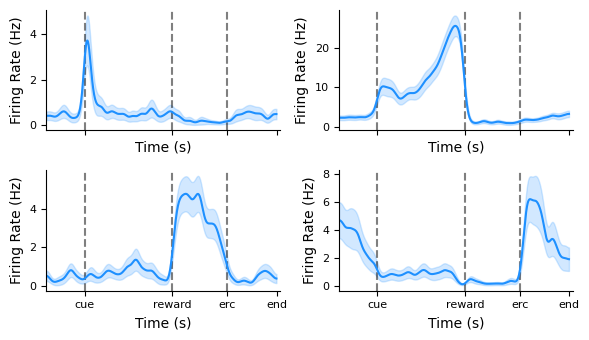

In [12]:
# plot some example cells
cluster_0 = gc.get_cluster("m6.2022-07-05.maze_cluster130")  # cue tuned
cluster_1 = gc.get_cluster("m2.2022-07-03.maze_cluster9")  # Nav tuned
cluster_2 = gc.get_cluster("m2.2022-06-30.maze_cluster34")  # RC tuned
cluster_3 = gc.get_cluster("m2.2022-07-12.maze_cluster54")  # ITI tuned

fig6, axes = plt.subplots(2, 2, figsize=(6, 3.5), clear=True, sharex=True)
cluster_0.plot_tuning(feature="trial_events", ax=axes[0, 0], feature_kwargs={"color": "dodgerblue"})
cluster_1.plot_tuning(feature="trial_events", ax=axes[0, 1], feature_kwargs={"color": "dodgerblue"})
cluster_2.plot_tuning(feature="trial_events", ax=axes[1, 0], feature_kwargs={"color": "dodgerblue"})
cluster_3.plot_tuning(feature="trial_events", ax=axes[1, 1], feature_kwargs={"color": "dodgerblue"})
fig6.tight_layout()

In [13]:
from GridMaze.analysis.event_aligned import cluster_heatmaps as ch

sessions = ch.get_sessions_for_analysis()
heatmap_df = ch.get_trial_aligned_activity_heatmap(
    sessions, smooth_SD=10, normalisation="zscore", cluster_method="KMeans", n_clusters=6, plot=False
)

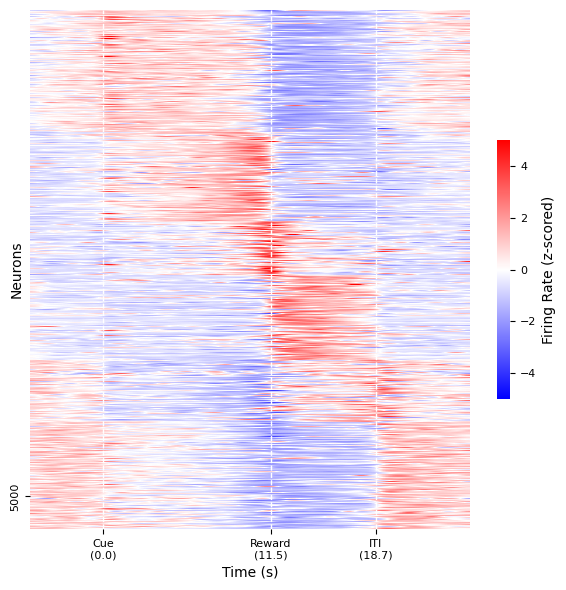

In [14]:
reload(ch)
fig5, ax = plt.subplots(1, 1, figsize=(6, 6), clear=True)
ch.plot_trial_aligned_heatmap(heatmap_df.firing_rate, normalisation_method="zscore", ax=ax)
fig5.tight_layout()

## Supp

In [ ]:
# load both LFP and CSD signal
LFP_signal_df = spectrograms.load_signal_df(signal_type="LFP")
CSD_signal_df = spectrograms.load_signal_df(signal_type="CSD")

In [ ]:
# plot average of raw signal aligned to event
f, axes = plt.subplots(2, 3, figsize=(5, 2), clear=True, width_ratios=[1, 2, 1])
spectrograms.plot_av_event_aligned_signal(LFP_signal_df, axes=axes[0, :])
spectrograms.plot_av_event_aligned_signal(CSD_signal_df, axes=axes[1, :])
for ax in axes[0, :]:
    ax.set_ylim(-0.5, 0.5)
for ax in axes[1, :]:
    ax.set_ylim(-0.1, 0.2)
f.savefig(FIG_SAVE_PATH / "event_aligned_LFP_CSD_signal.pdf")

In [ ]:
CSD_spectrogram_df = spectrograms.load_spectrogram_df(signal_type="CSD")

In [ ]:
f, axes = plt.subplots(1, 3, figsize=(6, 2), width_ratios=[0.4, 1, 0.35], clear=True)
spectrograms.plot_average_spectrogram(CSD_spectrogram_df, axes=axes)
f.savefig(FIG_SAVE_PATH / "event_aligned_CSD_spectrogram.pdf")

In [12]:
from GridMaze.analysis.event_aligned import cluster_heatmaps as ch

sessions = ch.get_sessions_for_analysis(aligned_to="event")
event_aligned_rates_df, ordering_df = ch.get_event_aligned_rates(sessions)

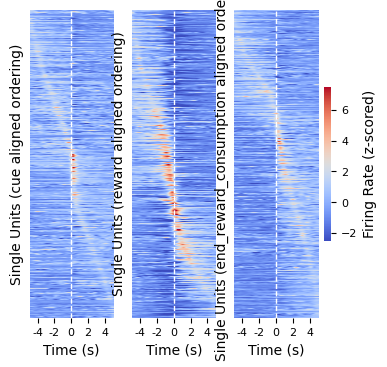

In [21]:
f, axes = plt.subplots(1, 3, figsize=(4, 4), clear=True, width_ratios=[1, 1, 1.25])
ch.plot_event_aligned_rates(event_aligned_rates_df, ordering_df, axes=axes)
f.savefig(FIG_SAVE_PATH / "event_aligned_population_activity.pdf")

In [ ]:
# pca neural trajectory plots
from GridMaze.analysis.event_aligned import dynamics as dyn

reload(dyn)
f2D, f3D_1, f3D_2, fL = dyn.plot_example_PC_trajectories(
    maze_name="maze_1",
    goal_subset="subset_2",
    late_sessions=False,
    PCs=(0, 1, 2),
    single_units=True,
)

f2D.savefig(FIG_SAVE_PATH / "example_PC_trajectory_2D.pdf")
f3D_1.savefig(FIG_SAVE_PATH / "example_PC_trajectory_3D_1.pdf")
f3D_2.savefig(FIG_SAVE_PATH / "example_PC_trajectory_3D_2.pdf")
fL.savefig(FIG_SAVE_PATH / "example_PC_trajectory_legend.pdf")